<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/focal_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


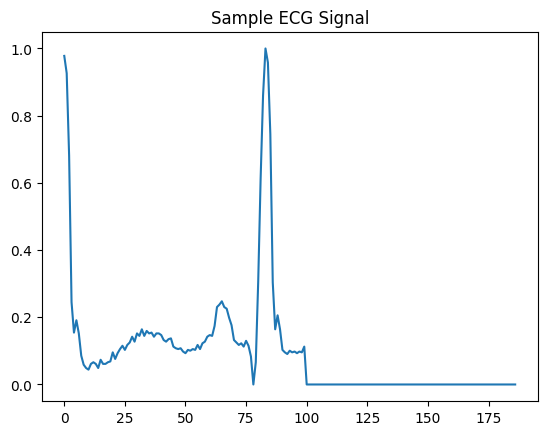

In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

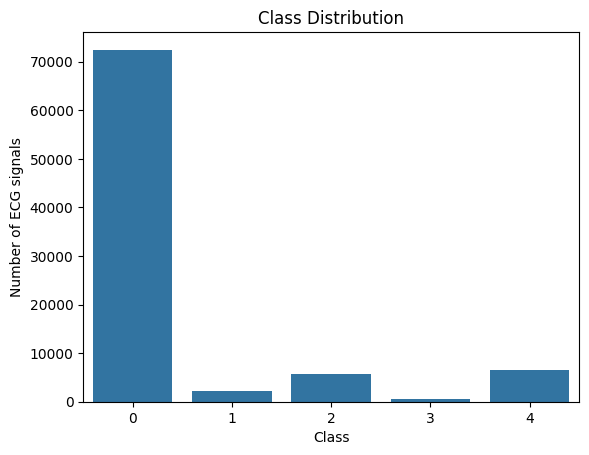

In [ ]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [ ]:
print(train.isna().sum().sum())
print(test.isna().sum().sum())

0
0


In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

X_train = np.array(X_train).reshape(-1,187,1)
X_val   = np.array(X_val).reshape(-1,187,1)
X_test  = np.array(X_test).reshape(-1,187,1)

In [ ]:
classes_unique = np.unique(y_res)
class_weights = compute_class_weight(class_weight='balanced', classes=classes_unique, y=y_res)
class_weights_dict = dict(zip(classes_unique, class_weights))
print("Class weights:", class_weights_dict)

Class weights: {np.float64(0.0): np.float64(1.0), np.float64(1.0): np.float64(1.0), np.float64(2.0): np.float64(1.0), np.float64(3.0): np.float64(1.0), np.float64(4.0): np.float64(1.0)}


In [ ]:
def categorical_focal_loss(gamma=2.0, alpha=None):
    """
    Multi-class Focal Loss (corrected version)
    y_true: one-hot
    y_pred: softmax
    """
    import tensorflow as tf
    alpha = tf.constant(alpha, dtype=tf.float32) if alpha is not None else 1.0

    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        ce = -y_true * tf.math.log(y_pred)
        if alpha is not None:
            ce *= alpha  # apply class weights per class
        focal = tf.pow(1 - y_pred, gamma) * ce
        return tf.reduce_mean(tf.reduce_sum(focal, axis=-1))  # mean over batch
    return loss_fn

In [ ]:
def mobilenet_ecg():
    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    # Compile with focal loss
    model.compile(
        optimizer='adam',
        loss=categorical_focal_loss(gamma=2.0, alpha=list(class_weights_dict.values())),
        metrics=['accuracy']
    )

    return model

model = mobilenet_ecg()

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 464s 100ms/step - accuracy: 0.9032 - loss: 0.1225 - val_accuracy: 0.8737 - val_loss: 0.1397
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 482s 106ms/step - accuracy: 0.9757 - loss: 0.0235 - val_accuracy: 0.9628 - val_loss: 0.0349
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 477s 105ms/step - accuracy: 0.9838 - loss: 0.0154 - val_accuracy: 0.9211 - val_loss: 0.0772
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 423s 93ms/step - accuracy: 0.9881 - loss: 0.0112 - val_accuracy: 0.8308 - val_loss: 0.2538
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 425s 94ms/step - accuracy: 0.9899 - loss: 0.0092 - val_accuracy: 0.9637 - val_loss: 0.0323
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 422s 93ms/step - accuracy: 0.9911 - loss: 0.0077 - val_accuracy: 0.8596 - val_loss: 0.2870
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 432s 95ms/step - accuracy: 0.9922 - loss: 0.0069 - val_accuracy: 0.9372 - val_loss: 0.0736
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 421s 93ms/step - accurac

In [21]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step
Validation MCC: 0.9840565727813498


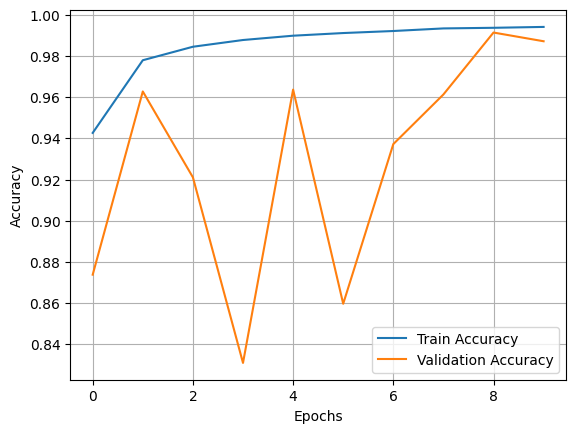

Final Training Accuracy: 0.9942
Final Validation Accuracy: 0.9872


In [22]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Display final training and validation accuracy
#final_train_acc = history.history['accuracy'][-1]
#final_val_acc = history.history['val_accuracy'][-1]
#print(f"Final Training Accuracy: {final_train_acc:.4f}")
#print(f"Final Validation Accuracy: {final_val_acc:.4f}")

# Final training & validation loss and accuracy

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]


print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

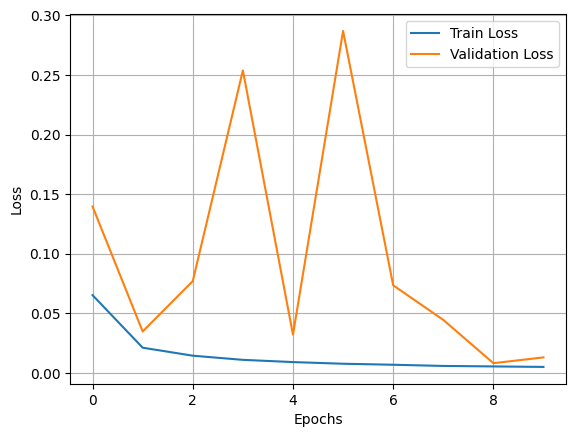

Final Training Loss: 0.0052
Final Validation Loss: 0.0131


In [23]:
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

In [24]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
y_test_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_test_pred))

Test Loss: 0.0443
Test Accuracy: 0.9779
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     18118
         1.0       0.79      0.74      0.76       556
         2.0       0.97      0.93      0.95      1448
         3.0       0.78      0.82      0.80       162
         4.0       1.00      0.96      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.90      0.89      0.90     21892
weighted avg       0.98      0.98      0.98     21892



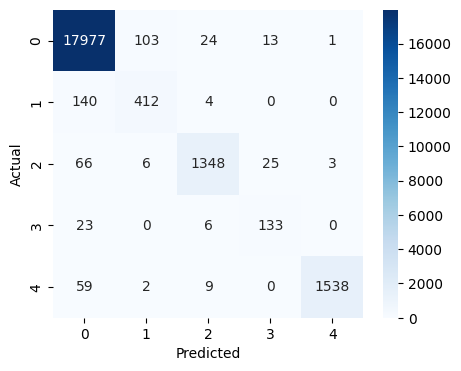

In [25]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

X_res = np.array(X_res).reshape(-1,187,1)

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=0
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)
    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1

Fold 2

Fold 3

Cross-validation accuracies: [0.9899325370788574, 0.9858922958374023, 0.9703274369239807]
Mean CV accuracy: 0.9820507566134135
